In [11]:
%env CUDA_VISIBLE_DEVICES=GPU-8868e167-e666-53c7-6c41-d8e83081f07e

env: CUDA_VISIBLE_DEVICES=GPU-8868e167-e666-53c7-6c41-d8e83081f07e


In [54]:
import pandas as pd
import numpy as np

#load data
data = pd.read_csv(r"/home/lero/idrive/cmac/DDMAP/stability_studies_master/stability_dataset_manual_edit.csv")
data = data.drop(data.columns[20:32], axis=1)
data.drop(['Unnamed: 0.6', 'Unnamed: 0.5', 'Unnamed: 0.4', 'Unnamed: 0.7'], axis=1, inplace=True)

#Store values for API/ polymer, condition
original_api = data['API']
original_polymer = data['Polymer']
original_condition = data['condition']

#fill pure api with 0 for polymer mol desc
pure = data['Polymer']=='Pure'
polymer_descriptors = data.columns[233:]
data.loc[pure, polymer_descriptors] = 0
suffix = '_polymer'
data.rename(columns={col: suffix+col for col in polymer_descriptors}, inplace=True)

#drop conditions since these have been split into temp/ humidity
data.drop(['condition'], axis=1, inplace=True)

#fill na values with average
data.fillna(data.mean(numeric_only=True), inplace=True)

#drop columns with a mean value of 0
print('original DataFrame shape\n', data.shape)
numeric_means=data.mean(numeric_only=True)
mean_of_0 = numeric_means[numeric_means==0].index
data.drop(mean_of_0, inplace=True, axis=1)

data.drop(['API', 'Polymer', 'Average days stable'], inplace=True, axis=1)

df = pd.DataFrame(data.columns[:12])
df.rename(columns={0: 'Features'}, inplace=True)
print('\nAPI and Polymer features\n\n', df)
print('\n\nShape of dataframe after removal of mean = 0\n', data.shape)

original DataFrame shape
 (4752, 449)

API and Polymer features

                  Features
0     Drug_loadings_(wt%)
1                 is_pure
2         days_stable_min
3         Polymer Tg (°C)
4      Polymer MW (g/mol)
5        Temperature (°C)
6          Humidity (%RH)
7                     GFA
8             API_Tm_(°C)
9             API_Tg_(°C)
10     API_Heat_of_Fusion
11  API_Entropy_of_Fusion


Shape of dataframe after removal of mean = 0
 (4752, 306)


,Drug_loadings_(wt%),is_pure,days_stable_min,Polymer Tg (°C),Polymer MW (g/mol),Temperature (°C),Humidity (%RH),GFA,API_Tm_(°C),API_Tg_(°C),...,_polymerfr_Al_OH_y,_polymerfr_Al_OH_noTert_y,_polymerfr_C_O_y,_polymerfr_C_O_noCOO_y,_polymerfr_NH0_y,_polymerfr_Ndealkylation2_y,_polymerfr_amide_y,_polymerfr_ester_y,_polymerfr_ether_y,_polymerfr_methoxy_y
0,20,0,90.0,97.1,90000.0,40,0,1,199.0,50.0,...,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,3.0
1,10,0,90.0,120.2,75100.0,40,75,1,199.0,50.0,...,2.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,14.0,6.0
2,70,0,90.0,110.6,58000.0,40,0,1,296.0,68.0,...,0.0,0.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0
3,80,0,90.0,71.1,118000.0,30,30,2,166.0,25.2,...,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,4.0,0.0
4,70,0,90.0,71.1,118000.0,30,30,2,166.0,25.2,...,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4747,20,0,0.0,71.1,118000.0,40,75,2,123.0,-7.0,...,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,4.0,0.0
4748,60,0,0.0,163.0,50000.0,40,75,2,123.0,-7.0,...,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0
4749,80,0,0.0,97.1,90000.0,40,75,2,123.0,-7.0,...,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,3.0
4750,50,0,0.0,120.2,75100.0,40,75,2,123.0,-7.0,...,2.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,14.0,6.0


In [13]:
##---Feature engineering---###
### perform sperately on API and polymer descriptors
#### API ####
threshold = 0.6
#remove correlated variables using spearman correlation coefficient
api_cols = data.columns[12:191].tolist()

corr_matrix = data[api_cols].corr(method='spearman')

# --- show correlated pairs ---
corr_pairs = corr_matrix.abs().unstack().sort_values(kind="quicksort", ascending=False)

high_corr_api = [
    (a, b) for a, b in corr_pairs.index
    if a != b and corr_pairs[(a, b)] > threshold
]

# --- upper triangle filtering ---
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

api_to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

In [14]:
##---Feature engineering---###
### perform sperately on API and polymer descriptors
#### Polymer ####

poly_cols = data.columns[192:].tolist()

corr_matrix = data[poly_cols].corr(method='spearman')

corr_pairs = corr_matrix.abs().unstack().sort_values(kind="quicksort", ascending=False)

high_corr_poly = [
    (a, b) for a, b in corr_pairs.index
    if a != b and corr_pairs[(a, b)] > threshold
]

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

poly_to_drop = [col for col in upper.columns if any(upper[col] > threshold)]


In [15]:
#drop correlated pairs
all_to_drop = list(set(api_to_drop + poly_to_drop))

data = data.drop(columns=all_to_drop)

print('length of dataframe\n', data.shape)

length of dataframe
 (4752, 79)


In [16]:
#Define Features for ColumnTransformer (AFTER ALL DROPS within dataframe) ---
categorical_features = ['API', 'Polymer']
# Identify numerical features:
dont_scale_features = data.drop(['days_stable_min', 'GFA', 'is_pure', ], axis=1).columns.tolist()
numerical_features = [col for col in dont_scale_features if col not in categorical_features]

In [17]:
#split data
X = data.drop(['days_stable_min'], axis=1)
y_non_binary = data['days_stable_min']
y = (y_non_binary>=90).astype(int)

In [18]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import SGDClassifier

models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000000),
        [
            {  
                'model__C': np.logspace(-4, 4, 20), 
                'model__l1_ratio': [0],
                'model__solver': ['lbfgs', 'newton-cg', 'sag'],
                'feature_selection__max_features': [20, 30, 50]
            },
            {
                'model__C': np.logspace(-3, 3, 8),
                'model__solver': ['liblinear'],
                'model__l1_ratio': [1],
                'feature_selection__max_features': [20, 30, 50]
            },
            {
                'model__C': np.logspace(-4, 4, 20),
                'model__penalty': ['elasticnet'],
                'model__solver': ['saga'],
                'model__l1_ratio': [0.1, 0.5, 0.9],
                'feature_selection__max_features': [20, 30, 50]
            }
        ]
    ),
    'SVC': (
        SVC(max_iter=10000000, random_state=42),
        {
            'model__C': [0.01, 0.1, 1, 2],
            'model__kernel': ['linear', 'poly', 'rbf'],
            'model__degree':[1,2,3,4,5],
            'model__gamma': [0.001, 0.01, 0.1, 1],
            'feature_selection__max_features': [20, 30, 50]
        }
    ),
    'K Neighbors Classifier': (
        KNeighborsClassifier(), 
        {
            'model__n_neighbors': np.arange(2,30,1),
            'feature_selection__max_features': [20, 30, 50]
        }
    ),
    'Random Forest Classifier': (
        RandomForestClassifier(random_state=42), 
        {
            'model__n_estimators': [300, 500, 1000],
            'model__max_features': ['sqrt', 'log2', None],
            'model__max_depth': [None, 1, 2, 3, 5, 10],
            'model__min_samples_split': [2, 5, 10, 20],
            'model__max_samples': [0.5, 0.7, 0.9, 1],
            'feature_selection__max_features': [20, 30, 50]
        }
    ),
    'XGBoost classifier': (
    XGBClassifier(
        random_state=42,
        eval_metric='logloss',
    ),
        {
            'model__booster': ['gbtree'],
            'model__max_depth': [3, 10, 20],
            'model__subsample': [0.5, 0.7, 0.9, 1],
            'model__colsample_bytree': [0.7, 0.9, 1],
            'model__learning_rate': [0.001],
            'model__n_estimators': [500, 800, 1000],
            'model__reg_alpha': [1e-5, 1e-2, 0.1, 1, 100],
            'feature_selection__max_features': [20, 30, 50]
        },
    ),
    'MLP Classifier': (
        MLPClassifier(max_iter=100000000, early_stopping=True), 
        {
            'model__hidden_layer_sizes': [(100,), (200,), (100, 50), (200, 200)],
            'model__activation': ['tanh', 'relu'],
            'model__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1],
            'model__solver': ['sgd', 'adam'],
            'model__learning_rate': ['adaptive'],
            'model__learning_rate_init': [0.001, 0.01],
            'feature_selection__max_features': [20, 30, 50]
        }
    )
}

In [19]:
#pre-processor for one-hot encoding and scaling
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[ 
        ('num', StandardScaler(), numerical_features),
    ],
    remainder = 'passthrough' # Keep any other columns not explicitly transformed (e.g., if there are any not in num or cat)
)

In [20]:
#Nested cv
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, GroupKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
import pickle
from sklearn.metrics import f1_score
import os
from tqdm.auto import tqdm

results = {}

scorer = {
    'F1_score': make_scorer(f1_score, average='binary'),
    'Accuracy': 'accuracy',
    'ROC-AUC': 'roc_auc'
}

#groups for GroupKFold
groups = (original_api.astype(str)).values

#GroupKFold for outer cv
outer_cv = GroupKFold(n_splits=5)
inner_cv = GroupKFold(n_splits=5)

#directory to save the models
save_directory = '/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Apr26_re_train/Classifier/SelectFromModel'
os.makedirs(save_directory, exist_ok=True)

for model_name, (classifier, param_grid) in tqdm(models.items(), desc='models', total=len(models)):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', SelectFromModel(estimator=RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10), threshold=-np.inf)),
        ('model', classifier)
    ])
    
    print('Model:', model_name)
  
    # Perform nested cross-validation
    grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=inner_cv, scoring=scorer, refit='F1_score', verbose=0, n_jobs=30)
    
    fit_params = {'groups': groups}
    
    # Evaluate outer loop scores
    nested_score = cross_validate(grid_search, X, y, groups=groups, cv=outer_cv, params=fit_params, scoring=scorer, n_jobs=1, return_train_score=False)
    
    # Get predictions
    predictions = cross_val_predict(grid_search, X, y, groups=groups, cv=outer_cv, params=fit_params, method='predict', n_jobs=1)

    # Fit to find best parameters
    grid_search.fit(X, y, **fit_params)
    best_params = grid_search.best_params_
    
    # Save the best model
    best_model = grid_search.best_estimator_
    model_file_path = os.path.join(save_directory, f'{model_name}_best_model.pkl')
    with open(model_file_path, 'wb') as model_file:
        pickle.dump(best_model, model_file)

    results[model_name] = {
        'nested_score': nested_score,
        'ground_truth': y.values,
        'predictions': predictions,
        'best_params': best_params,
    }

dictionary_file_path = os.path.join(save_directory, 'SelectFromModelClassifiers_results_dictionary.pkl')   
with open(dictionary_file_path, 'wb') as f:
    pickle.dump(results, f)

print('Finito')

models:   0%|                                                                                     | 0/6 [00:00<?, ?it/s]

Model: Logistic Regression


/home/lero/.conda/envs/LeRo_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lero/.conda/envs/LeRo_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lero/.conda/envs/LeRo_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be re

KeyboardInterrupt: 

In [ ]:
#Ensemble
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score, GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
import pickle
from sklearn.metrics import f1_score
import os
from tqdm.auto import tqdm
from sklearn.ensemble import StackingClassifier
from sklearn.base import clone

##Load pre-trained base models 
with open('/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Classifier/January_re-run/Random Forest Classifier_best_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

with open('/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Classifier/January_re-run/XGBoost classifier_best_model.pkl', 'rb') as f:
    XGB_model = pickle.load(f)

with open('/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Classifier/January_re-run/MLP Classifier_best_model.pkl', 'rb') as f:
    MLP_model = pickle.load(f)

with open('/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Classifier/January_re-run/SVC_best_model.pkl', 'rb') as f:
    SVC_model = pickle.load(f)

with open('/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Classifier/January_re-run/Logistic Regression_best_model.pkl', 'rb') as f:
    log_model = pickle.load(f)

groups = (original_api.astype(str)).values

outer_cv = GroupKFold(n_splits=5) 

base_models=[
    ('Random Forest Classifier', rf_model),
    ('XGBoost Classifier', XGB_model),
    ('MLP Classifier', MLP_model),
    ('SVC', SVC_model),
    ('log regression', log_model)
]


#prepare out of fold predictions which have not seen test data
train_oof_predictions = pd.DataFrame(index=X.index)

for name, model in base_models:
    model_clone = clone(model)

    if hasattr(model_clone, 'predict_proba'):
        oof_predictions = cross_val_predict(model_clone, X, y, groups=groups, cv=outer_cv, method='predict_proba', n_jobs=50)[:, 1] #take probabilities only, not n_samples too within 2D array
    else:
        oof_predictions = cross_val_predict(model_clone, X, y, groups=groups, cv=outer_cv, method='decision_function', n_jobs=10)
        
    train_oof_predictions[name]=oof_predictions 


meta_models_tuning = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000000, random_state=42),
        [
            {  
                'C': np.arange(0.1,2,0.1), 
                'l1_ratio': [0],
                'solver': ['lbfgs', 'newton-cg', 'sag']
            },
            {
                'C': np.arange(0.1,2,0.1),
                'solver': ['liblinear'],
                'l1_ratio': [1],
            },
            {
                'C': np.arange(0.1,2,0.1),
                'penalty': ['elasticnet'],
                'solver': ['saga'],
                'l1_ratio': [0.1, 0.5, 0.9]
            }
        ]
    ),
    'SVC': (
        SVC(max_iter=10000000, random_state=42),
        {
            'C': [0.01, 0.1, 1, 2],
            'kernel': ['poly', 'rbf'],
            'degree':[1,2,3,4,5],
            'gamma': [0.001, 0.01, 0.1, 1],
        }
    ),
    'Random Forest Classifier': (
        RandomForestClassifier(random_state=42), 
        {
            'n_estimators': [10, 50, 100],
            'max_features': [5, 10, 20, 'sqrt', 'log2', None],
            'max_depth': [None, 3, 10, 20],
            'min_samples_split': [2, 5, 10, 20]
        }
    ),
    'XGBoost classifier': (
        XGBClassifier(random_state=42),
        {
            'max_depth': [3, 10, 20],
            'subsample': [0.5, 0.7, 0.9, 1],
            'colsample_bytree': [0.5, 0.7, 0.9, 1],
            'learning_rate': [0.001, 0.01],
            'n_estimators': [50, 100, 200],
        }
    ),
}

results = {}
scorer = make_scorer(f1_score, average='binary')

meta_cv = GroupKFold(n_splits=5)
inner_cv = GroupKFold(n_splits=5)

for model_name, (classifier, param_grid) in meta_models_tuning.items():
    print('model:', model_name)
    
    grid_search = GridSearchCV(estimator=classifier, param_grid=param_grid, cv=inner_cv, scoring=scorer, verbose=0, n_jobs=30)

    fit_params = {'groups': groups}
    
    stacked_evaluation_scores = cross_val_score(grid_search, train_oof_predictions, y, groups=groups, params=fit_params, cv=meta_cv, n_jobs=1, scoring=scorer)
    predictions = cross_val_predict(grid_search, train_oof_predictions, y, groups=groups, cv=meta_cv, params=fit_params, method='predict', n_jobs=1)
    
    print(model_name, stacked_evaluation_scores)
    print(f'{model_name} mean stacked scores:', stacked_evaluation_scores.mean())


    #directory to save the models
    save_directory = '/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Classifier/January_re-run/stacking'
    os.makedirs(save_directory, exist_ok=True)

    grid_search.fit(train_oof_predictions, y, **fit_params)
    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_
    

    model_file_path = os.path.join(save_directory, f'{model_name}_best_model.pkl')
    with open(model_file_path, 'wb') as model_file:
        pickle.dump(best_model, model_file)

    results[model_name] = {
        'nested_score': stacked_evaluation_scores,
        'ground_truth': y.values,
        'predictions': predictions,
        'best_params': best_params,
    }

dictionary_file_path = os.path.join(save_directory, 'classifiers_results_dictionary.pkl')   
with open(dictionary_file_path, 'wb') as f:
    pickle.dump(results, f)

print('Finito')

In [41]:
#model scoring
import pickle
import pandas as pd
import numpy as np
import os


with open('/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Apr26_re_train/Classifier/Test_set_Classifiers_results_dictionary.pkl', 'rb') as f:
    results = pickle.load(f)

records = []

for model in results:
    scores = results[model]['nested_score']
    
    row = {'Model': model}   # FIXED
    
    for metric in ['test_F1_score', 'test_Accuracy', 'test_ROC-AUC']:
        values = scores[metric]
        mean_score = np.mean(values)
        rsd_score = (np.std(values) / mean_score) * 100
        
        row[f'{metric}_mean'] = mean_score
        row[f'{metric}_%RSD'] = rsd_score
    
    records.append(row)

results_df = pd.DataFrame(records)
results_df.to_csv('/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Apr26_re_train/Classifier/SelectFromModel/results.csv')
results_df

,Model,test_F1_score_mean,test_F1_score_%RSD,test_Accuracy_mean,test_Accuracy_%RSD,test_ROC-AUC_mean,test_ROC-AUC_%RSD
0,Logistic Regression,0.726740,2.988856,0.685582,4.071830,0.795144,2.866046
1,SVC,0.687869,4.616248,0.630622,11.515510,0.759856,7.773770
2,K Neighbors Classifier,0.686706,8.091675,0.679134,6.428154,0.728318,6.561181
3,Random Forest Classifier,0.703081,5.302547,0.655324,10.261235,0.786967,3.683879
4,XGBoost classifier,0.710827,6.676980,0.658267,10.320634,0.785521,5.113930
5,MLP Classifier,0.730894,6.913804,0.704365,6.479758,0.795435,5.238591


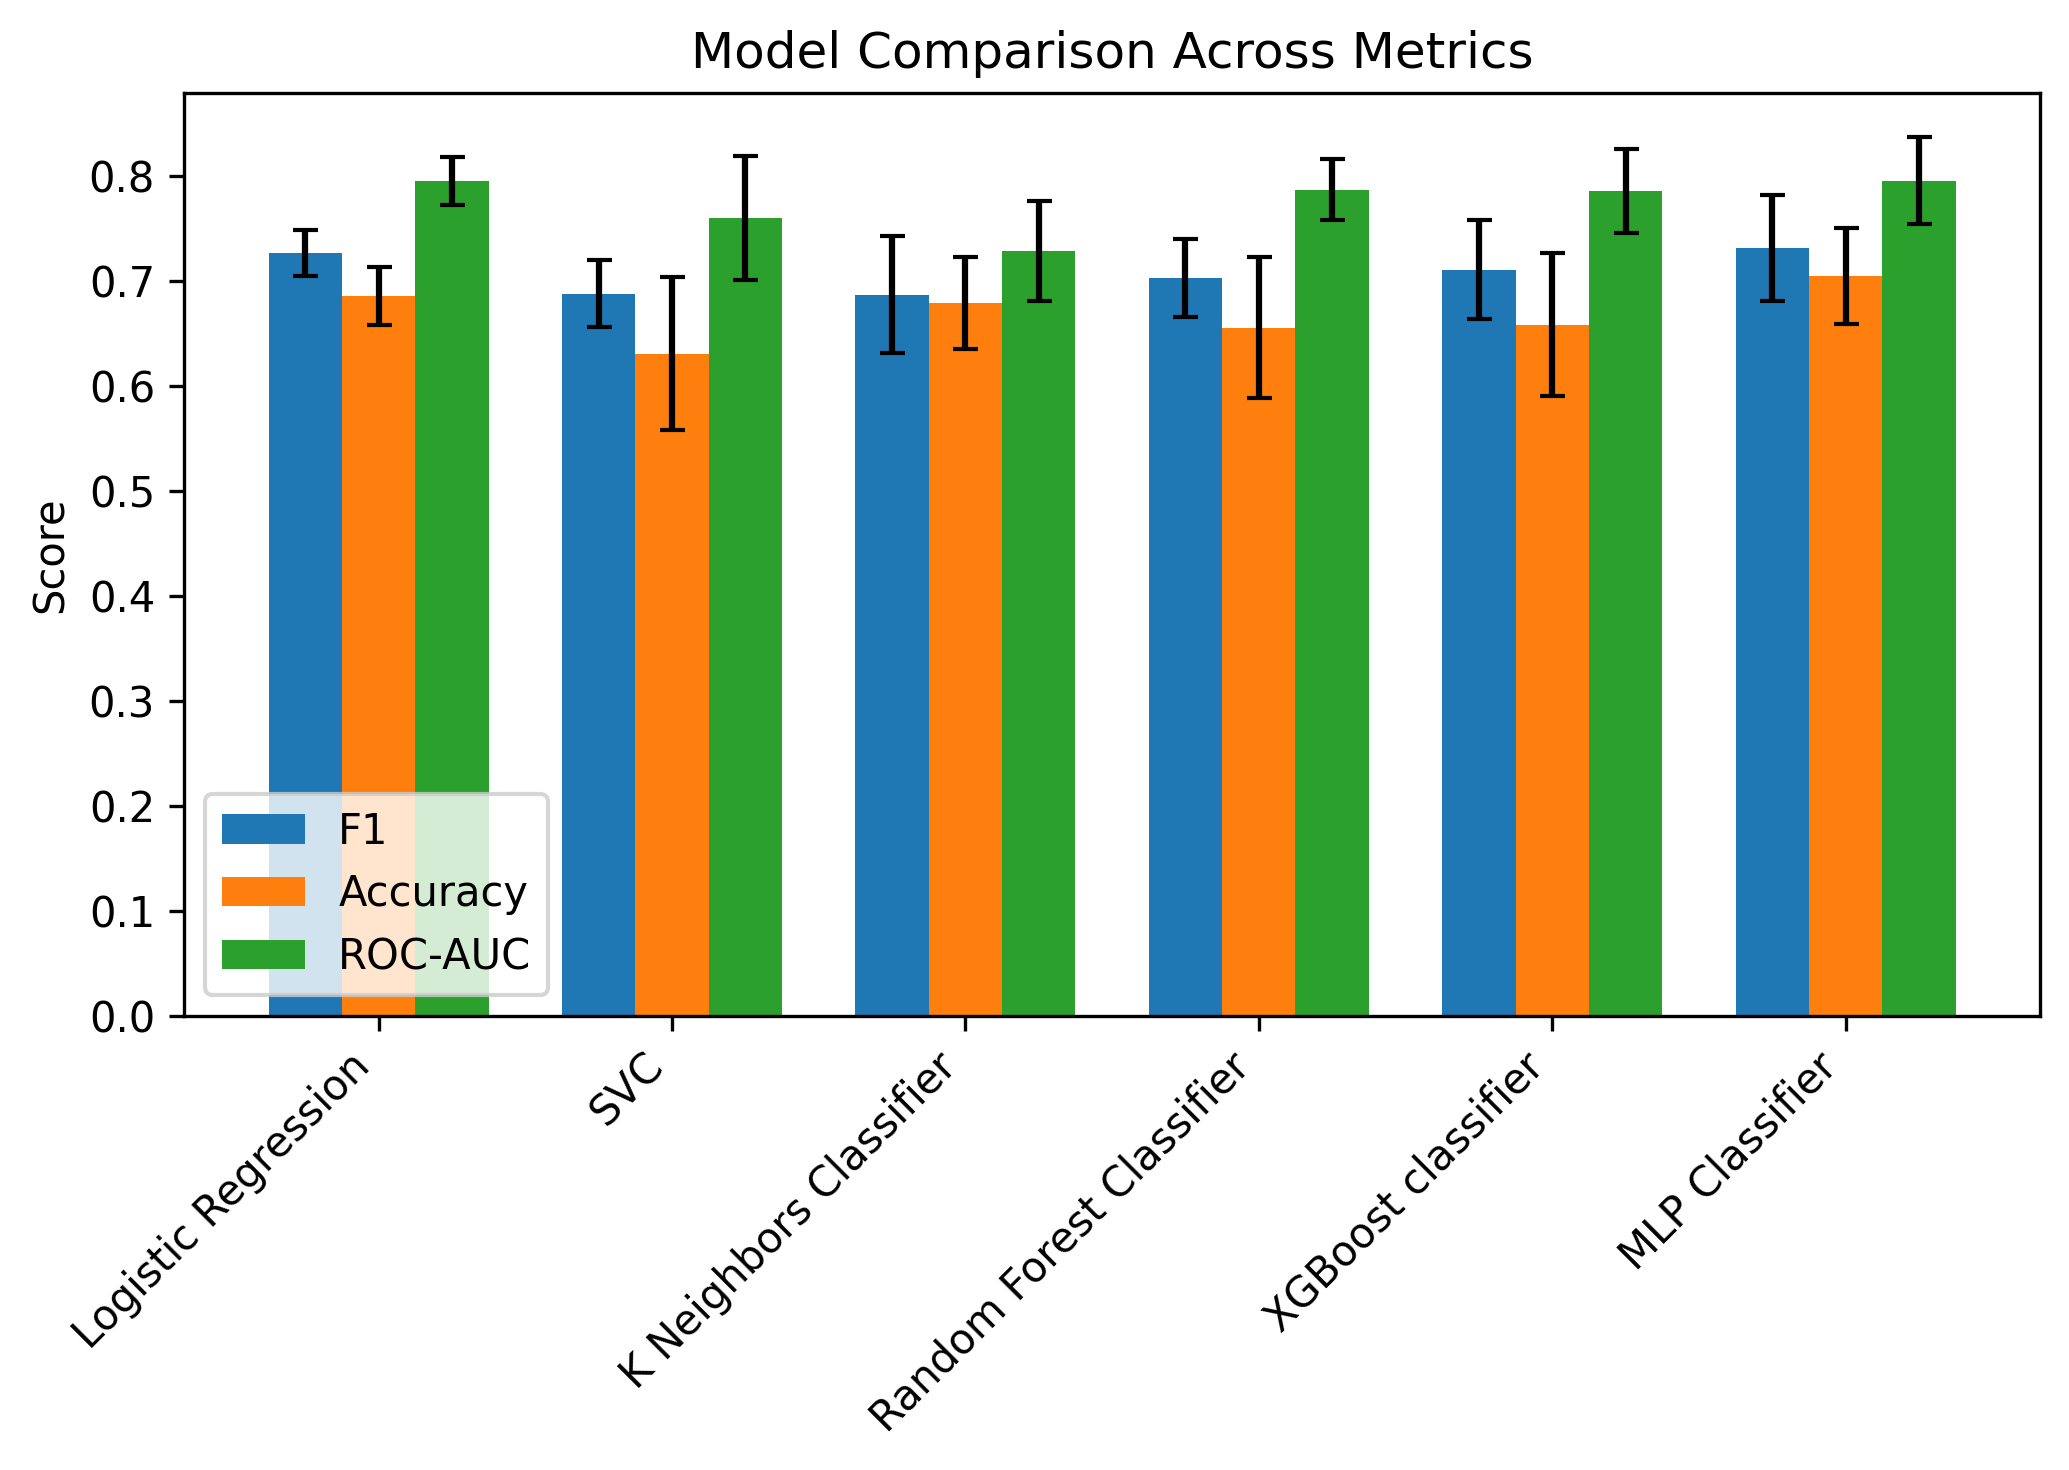

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import os 

save_dir = '/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Apr26_re_train/Classifier/SelectFromModel/plots'
os.makedirs(save_dir, exist_ok=True)

plot_df = results_df.melt(
    id_vars='Model',
    value_vars=[
        'test_F1_score_mean',
        'test_Accuracy_mean',
        'test_ROC-AUC_mean'
    ],
    var_name='Metric',
    value_name='Score'
)
plot_df['Metric'] = plot_df['Metric'].map({
    'test_F1_score_mean': 'F1',
    'test_Accuracy_mean': 'Accuracy',
    'test_ROC-AUC_mean': 'ROC-AUC'
})

error_df = results_df.melt(
    id_vars='Model',
    value_vars=[
        'test_F1_score_%RSD',
        'test_Accuracy_%RSD',
        'test_ROC-AUC_%RSD'
    ],
    var_name='Metric',
    value_name='RSD'
)

error_df['Metric'] = error_df['Metric'].map({
    'test_F1_score_%RSD': 'F1',
    'test_Accuracy_%RSD': 'Accuracy',
    'test_ROC-AUC_%RSD': 'ROC-AUC'
})

plot_df = plot_df.merge(error_df, on=['Model', 'Metric'])
plot_df['Error'] = plot_df['Score'] * plot_df['RSD'] / 100

models = results_df['Model']
metrics = ['test_F1_score_mean', 'test_Accuracy_mean', 'test_ROC-AUC_mean']

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(7,5), dpi=300)

for i, metric in enumerate(metrics):
    scores = results_df[metric]
    rsd = results_df[metric.replace('_mean', '_%RSD')]
    errors = scores * rsd / 100
    
    plt.bar(
        x + i*width,
        scores,
        width,
        label=metric.split('_')[1],
        yerr=errors,
        capsize=3
    )

plt.xticks(x + width, models, rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Model Comparison Across Metrics')
plt.legend()
plt.tight_layout()
plot_filename = os.path.join(save_dir, f'Models comparison across scoring metrics')
plt.savefig(plot_filename)
plt.show()

In [47]:
with open('/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Apr26_re_train/Classifier/MLP Classifier_best_model.pkl', 'rb') as f:
    pipeline = pickle.load(f)

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [ ]:
#Visualise model scores
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List to hold each report entry as a dictionary
reports_list = []

for model in results:
    # Obtain the classification report as a dictionary
    report = classification_report(results[model]['ground_truth'], 
                                   results[model]['predictions'], 
                                   output_dict=True, 
                                   digits=2)
    
    # Flatten the dictionary and add to reports_list
    for class_label, metrics in report.items():
        if isinstance(metrics, dict):  # Ignore the 'accuracy' mean metrics lines
            for metric_name, metric_value in metrics.items():
                reports_list.append({
                    "Model": model,
                    "Class": class_label,
                    "Metric": metric_name,
                    "Value": metric_value
                })

# Convert the list of dictionaries into a DataFrame
reports_df = pd.DataFrame(reports_list)

# Create pivot table to organize data better
pivot_table = reports_df.pivot_table(index=['Model', 'Class'], 
                                     columns='Metric', 
                                     values='Value')

pivot_table.drop(columns='support', inplace=True)

plt.figure(figsize = (8,6), dpi=500)
sns.heatmap(pivot_table, annot = True)
plt.title('Classification Report Metrics Heatmap')
plt.xlabel('Metrics')
plt.xticks(rotation =45)
plt.ylabel('Model and Class')
plt.tight_layout()
#save_directory = '/projects/cp/se_users/ksrn200/Classifier/GroupKFold/Plots/One_week_stability'
#plot_filename = os.path.join(save_directory, 'classification_report.png')
#plt.savefig(plot_filename)

plt.show()


# Display the pivot table
print(pivot_table)

In [ ]:
#visualisation of model performance
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import os


for model in results:
    print(model)
    cf_matrix = confusion_matrix(results[model]['ground_truth'], results[model]['predictions'])
    print(cf_matrix)
    print(classification_report(results[model]['ground_truth'], results[model]['predictions'], digits=2))
    plt.figure(figsize=(5,5), dpi=500)
    plt.title(f'{model}: results')
    sns.heatmap(normalize(cf_matrix, axis=1, norm='l1'), annot=True, fmt='.2%', cmap='Blues')
    plt.xlabel('predicted values')
    plt.ylabel('actual values')
    plt.xticks(ticks=[0.5, 1.5], labels=['0', '1'], fontsize=10, rotation=0)
    plt.yticks(ticks=[0.5, 1.5], labels=['0', '1'], fontsize=10, rotation=0)
    
    save_directory = '/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results'
    plot_filename = os.path.join(save_directory, f'{model}_results.png')
    plt.savefig(plot_filename)
    
    plt.show()


In [43]:
#######--------parameters of importance---------#############
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Load the model pipeline
with open('/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Apr26_re_train/Classifier/MLP Classifier_best_model.pkl', 'rb') as f:
    pipeline = pickle.load(f)
    
# Transform the features
X_transformed = pipeline.named_steps['preprocessor'].transform(X)

model = pipeline.named_steps['model']

importances = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({'feature': feature_names, 'Importance': importances})
importance_df.sort_values(by = 'Importance', inplace=True, ascending=False)
top_parameters = importance_df.iloc[:10]
print(top_parameters)

plt.figure(figsize=(10,7), dpi=500)
sns.barplot(top_parameters, x='feature', y='Importance')
plt.title('Feature importance using Random Forest classifier')
plt.xticks(rotation =90)
plt.xlabel('Features')
plt.ylabel('Mean accuracy decrease')
plt.tight_layout()
#save_directory = '/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results'
#plot_filename = os.path.join(save_directory, 'XGBoost_classifier_feature_importance.png')
#plt.savefig(plot_filename)
plt.show()


AttributeError: 'MLPClassifier' object has no attribute 'feature_importances_'

In [ ]:
########---------PCA parameters of importance----------##########
##Inner-CV performance trends, averaged across hyperparameter settings##

import matplotlib.pyplot as plt

save_directory = '/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Classifier/January_re-run/PCA'
os.makedirs(save_directory, exist_ok=True)

for model in results:
    print(model)
    
    pca_summary = results[model]['PCA_n_components_score']
    print(PCA_summary)
    
    plt.figure(figsize=(4,3), dpi=200)
    plt.errorbar(pca_summary['n_components'], pca_summary['mean'], yerr=pca_summary['std'], capsize=3, marker='o')
    plt.xlabel('n_components')
    plt.ylabel('classification accuracy')
    plt.yticks(np.arange(0,1, step=0.1))
    plt.title(f'{model} performance vs\n PCA dimensionality')
    plt.tight_layout()
    plot_filename = os.path.join(save_directory, f'{model}_performance_vs_pca_n_components.png')
    plt.savefig(plot_filename)
    plt.show

100%|███████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 26.77it/s]


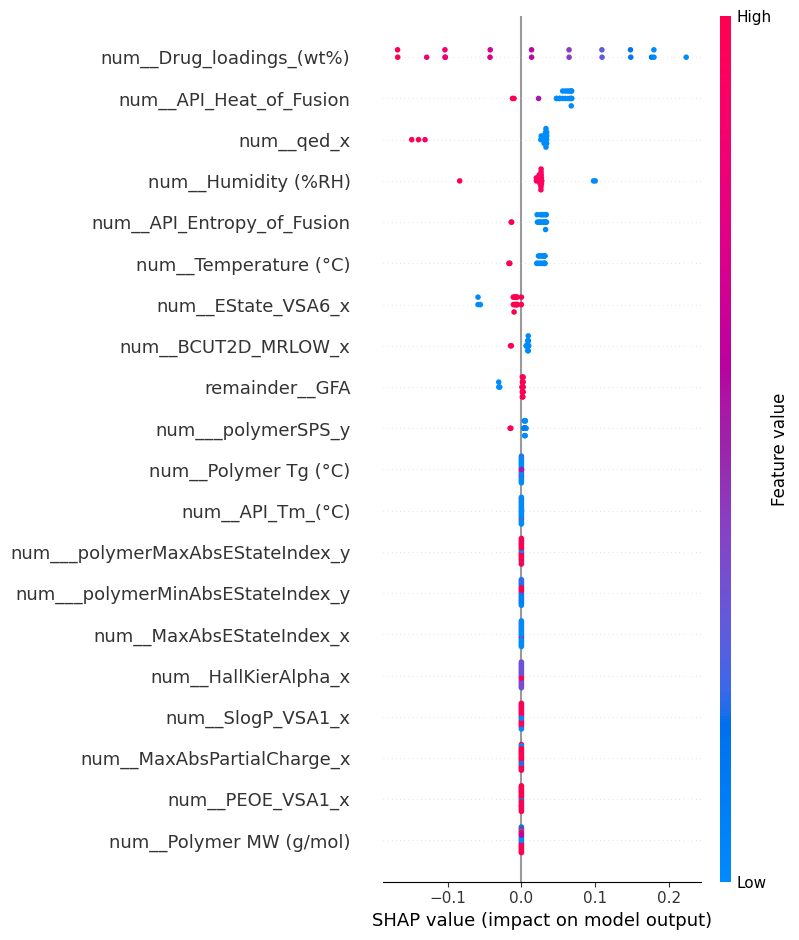

In [52]:
import shap
import numpy as np

with open('/home/lero/idrive/cmac/DDMAP/Stability studies/Model_results/Apr26_re_train/Classifier/Logistic Regression_best_model.pkl', 'rb') as f:
    pipeline = pickle.load(f)

# extract from pipeline explicitly
model = pipeline.named_steps['model']
preprocessor = pipeline.named_steps['preprocessor']
selector = pipeline.named_steps['feature_selection']

# transform pipeline inputs correctly
X_transformed = preprocessor.transform(X)
X_selected = selector.transform(X_transformed)
X_selected = np.array(X_selected)

background = X_selected[np.random.choice(X_selected.shape[0], 50, replace=False)]
X_sample = X_selected[:20]

# model wrapper (binary classification)
def model_fn(X):
    return model.predict_proba(X)[:, 1]

explainer = shap.KernelExplainer(model_fn, background)

shap_values = explainer.shap_values(X_sample)

# sanity check
assert shap_values.shape == X_sample.shape

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=np.array(selected_feature_names)
)